# ROGII — Wellbore Geology Prediction
## Notebook 1: Exploratory Data Analysis

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from data_utils import *

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

DATA_DIR = Path('../data')

## 1. Load All Wells

In [2]:
train = load_all_wells(DATA_DIR, split='train')
test  = load_all_wells(DATA_DIR, split='test')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'\nTrain columns: {list(train.columns)}')
print(f'Test  columns: {list(test.columns)}')
print(f'\nSubmission rows: {len(sample_sub)}')
print(sample_sub.head())

Loaded train: 773 wells, 5,092,255 rows, 16 columns
Loaded test: 3 wells, 19,221 rows, 9 columns

Train columns: ['row_idx', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'well_id', 'tw_GR']
Test  columns: ['row_idx', 'MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'well_id', 'tw_GR']

Submission rows: 14151
              id  tvt
0  000d7d20_1442  0.0
1  000d7d20_1443  0.0
2  000d7d20_1444  0.0
3  000d7d20_1445  0.0
4  000d7d20_1446  0.0


In [3]:
# Overview
print('=== TRAIN ===')
display(train.describe().T.round(2))
print('\n=== TEST ===')
display(test.describe().T.round(2))

=== TRAIN ===


,count,mean,std,min,25%,50%,75%,max
row_idx,5092255.0,3423.70,2124.71,0.00,1646.00,3297.00,4995.00,12140.00
MD,5092255.0,14316.86,2206.52,9335.00,12547.00,14199.00,15928.00,22964.00
X,5092255.0,2965999.12,47749.98,2855426.45,2917842.12,2986283.76,3006569.49,3039107.26
Y,5092255.0,1074747.73,35603.54,1007175.50,1040715.98,1080802.93,1105966.98,1141857.53
Z,5092255.0,-9390.81,634.48,-11027.65,-9920.91,-9270.31,-8918.93,-7174.22
ANCC,5046621.0,-9008.72,637.62,-10647.31,-9548.06,-8865.57,-8511.81,-7301.76
ASTNU,5092255.0,-9192.69,641.86,-10852.79,-9723.75,-9063.21,-8691.07,-7509.20
ASTNL,5092255.0,-9257.05,626.88,-10865.58,-9771.82,-9134.01,-8765.32,-7614.43
EGFDU,5092255.0,-9350.50,622.00,-10887.58,-9883.51,-9213.22,-8860.12,-7704.03
EGFDL,5086188.0,-9392.21,622.22,-10932.35,-9925.56,-9256.61,-8902.37,-7731.61



=== TEST ===


,count,mean,std,min,25%,50%,75%,max
row_idx,19221.0,3270.69,1962.57,0.00,1601.00,3203.00,4805.00,7558.00
MD,19221.0,14445.56,2051.40,10456.00,12768.00,14370.00,15972.00,19136.00
X,19221.0,2988708.54,16865.40,2967726.49,2970539.63,2983526.03,3007759.48,3010760.08
Y,19221.0,1074573.18,10628.10,1060431.23,1063828.98,1071992.31,1086228.61,1089521.36
Z,19221.0,-9665.87,394.95,-10182.58,-10058.00,-9698.16,-9302.14,-8356.04
GR,15437.0,76.46,30.49,21.89,45.67,83.04,97.30,219.81
TVT_input,5070.0,11626.65,365.22,10606.18,11455.83,11600.31,11755.67,12225.05
tw_GR,19221.0,52.09,23.99,30.12,39.86,40.05,40.95,208.93


## 2. Missing Values

In [4]:
for label, df in [('TRAIN', train), ('TEST', test)]:
    miss = df.isnull().mean().mul(100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f'--- {label} missing % ---')
    print(miss.to_string() if len(miss) else 'None')
    print()

--- TRAIN missing % ---
TVT_input    74.3
GR           29.6
ANCC          0.9
EGFDL         0.1

--- TEST missing % ---
TVT_input    73.6
GR           19.7



## 3. Target Distribution (TVT)

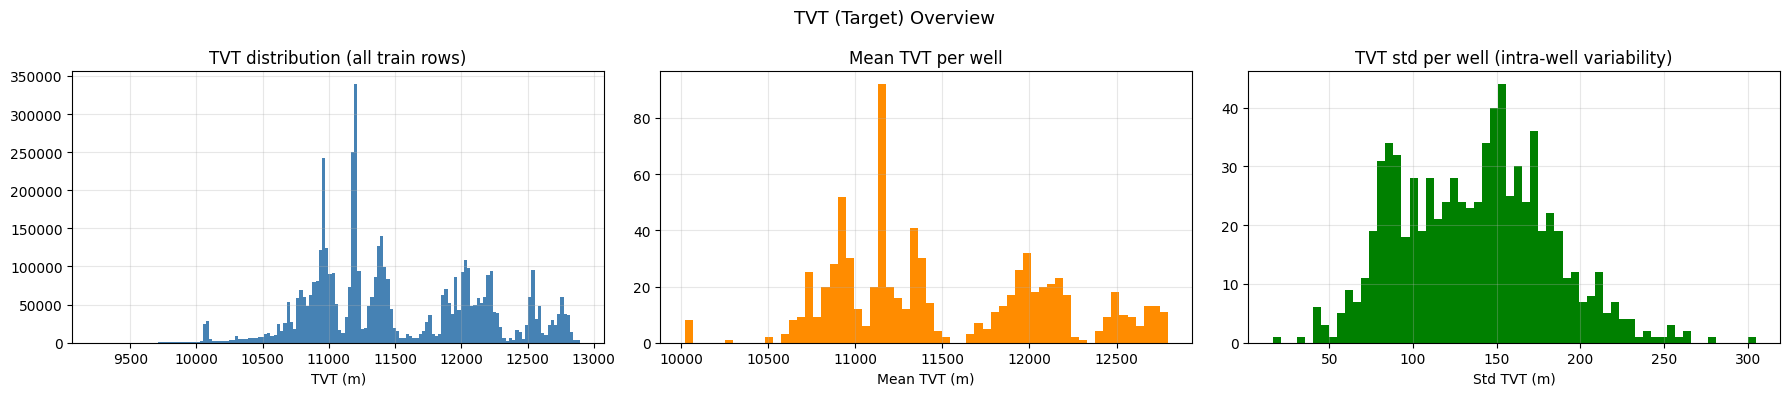

count    5092255.00
mean       11503.64
std          639.97
min         9245.19
25%        10987.93
50%        11354.51
75%        12038.26
max        12893.89
Name: TVT, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(train[TARGET_COL], bins=150, color='steelblue', edgecolor='none')
axes[0].set_title('TVT distribution (all train rows)')
axes[0].set_xlabel('TVT (m)')

# Per-well mean TVT
well_tvt_mean = train.groupby(WELL_COL)[TARGET_COL].mean()
axes[1].hist(well_tvt_mean, bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('Mean TVT per well')
axes[1].set_xlabel('Mean TVT (m)')

# Per-well TVT std (intra-well variability)
well_tvt_std = train.groupby(WELL_COL)[TARGET_COL].std()
axes[2].hist(well_tvt_std, bins=60, color='green', edgecolor='none')
axes[2].set_title('TVT std per well (intra-well variability)')
axes[2].set_xlabel('Std TVT (m)')

plt.suptitle('TVT (Target) Overview', fontsize=13)
plt.tight_layout()
plt.show()

print(train[TARGET_COL].describe().round(2))

## 4. TVT_input vs TVT — How Much is Pre-Filled?

Train: TVT_input == TVT in 25.7% of rows
Test:  TVT_input == 0   in 0.0% of rows  (these are the rows to predict)


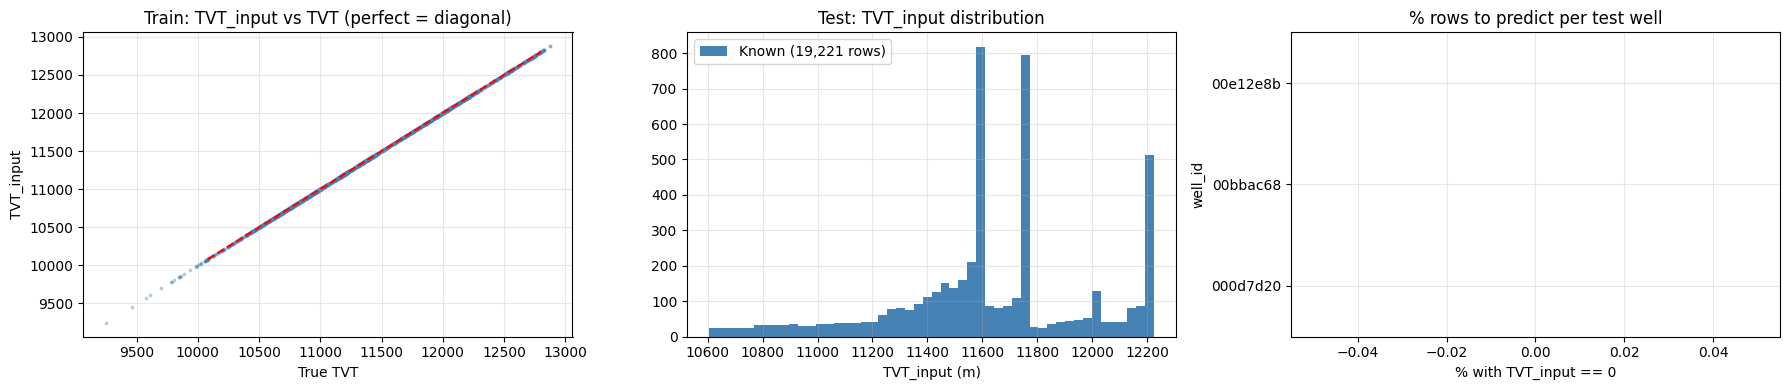

In [6]:
# In train: TVT_input should equal TVT (it's the full expert interpretation)
# In test:  TVT_input is 0 for the rows we need to predict

train_match = (train[TVTINPUT_COL] == train[TARGET_COL]).mean() * 100
test_zero   = (test[TVTINPUT_COL] == 0).mean() * 100

print(f'Train: TVT_input == TVT in {train_match:.1f}% of rows')
print(f'Test:  TVT_input == 0   in {test_zero:.1f}% of rows  (these are the rows to predict)')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# TVT_input vs TVT scatter (train)
sample_idx = np.random.choice(len(train), min(10000, len(train)), replace=False)
axes[0].scatter(train[TARGET_COL].iloc[sample_idx],
                train[TVTINPUT_COL].iloc[sample_idx],
                alpha=0.3, s=3, c='steelblue')
lo, hi = train[TARGET_COL].quantile(0.01), train[TARGET_COL].quantile(0.99)
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5)
axes[0].set_title('Train: TVT_input vs TVT (perfect = diagonal)')
axes[0].set_xlabel('True TVT')
axes[0].set_ylabel('TVT_input')

# Test TVT_input distribution
test_known  = test[test[TVTINPUT_COL] != 0][TVTINPUT_COL]
test_unknwn = test[test[TVTINPUT_COL] == 0]
axes[1].hist(test_known, bins=50, color='steelblue', label=f'Known ({len(test_known):,} rows)')
axes[1].set_title('Test: TVT_input distribution')
axes[1].set_xlabel('TVT_input (m)')
axes[1].legend()

# Per-test-well: fraction to predict
per_well = test.groupby(WELL_COL)[TVTINPUT_COL].apply(lambda x: (x==0).mean()*100)
per_well.plot.barh(ax=axes[2], color='tomato')
axes[2].set_title('% rows to predict per test well')
axes[2].set_xlabel('% with TVT_input == 0')

plt.tight_layout()
plt.show()

## 5. GR Log Analysis

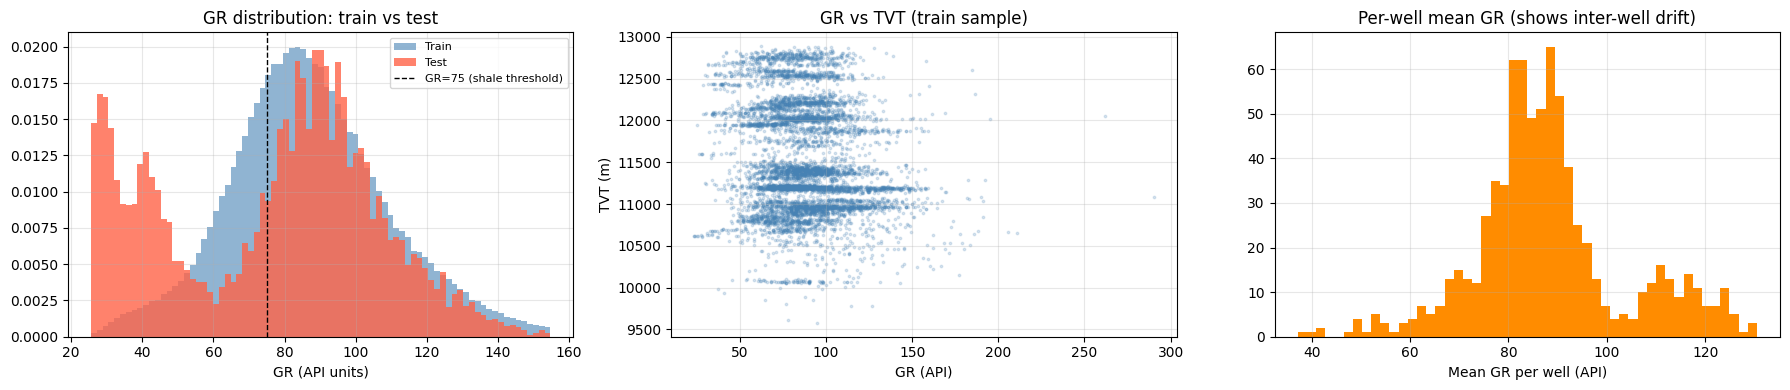

GR mean ranges: 37.2 to 130.5 API across wells
→ Per-well normalization is important


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Train vs test GR distribution
lo = min(train[GR_COL].quantile(0.01), test[GR_COL].quantile(0.01))
hi = max(train[GR_COL].quantile(0.99), test[GR_COL].quantile(0.99))
bins = np.linspace(lo, hi, 80)
axes[0].hist(train[GR_COL], bins=bins, density=True,
             alpha=0.6, color='steelblue', label='Train')
axes[0].hist(test[GR_COL], bins=bins, density=True,
             alpha=0.8, color='tomato', label='Test')
axes[0].axvline(75, color='black', ls='--', lw=1, label='GR=75 (shale threshold)')
axes[0].set_title('GR distribution: train vs test')
axes[0].set_xlabel('GR (API units)')
axes[0].legend(fontsize=8)

# GR vs TVT scatter
axes[1].scatter(train[GR_COL].iloc[sample_idx],
                train[TARGET_COL].iloc[sample_idx],
                alpha=0.2, s=3, c='steelblue')
axes[1].set_title('GR vs TVT (train sample)')
axes[1].set_xlabel('GR (API)')
axes[1].set_ylabel('TVT (m)')

# Per-well GR mean variability
gr_means = train.groupby(WELL_COL)[GR_COL].mean()
axes[2].hist(gr_means, bins=50, color='darkorange', edgecolor='none')
axes[2].set_title('Per-well mean GR (shows inter-well drift)')
axes[2].set_xlabel('Mean GR per well (API)')

plt.tight_layout()
plt.show()

print(f'GR mean ranges: {gr_means.min():.1f} to {gr_means.max():.1f} API across wells')
print('→ Per-well normalization is important')

## 6. Resistivity Logs (Train Only)

Resistivity cols in train: ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
(These are NOT available in test — cannot be direct model features)



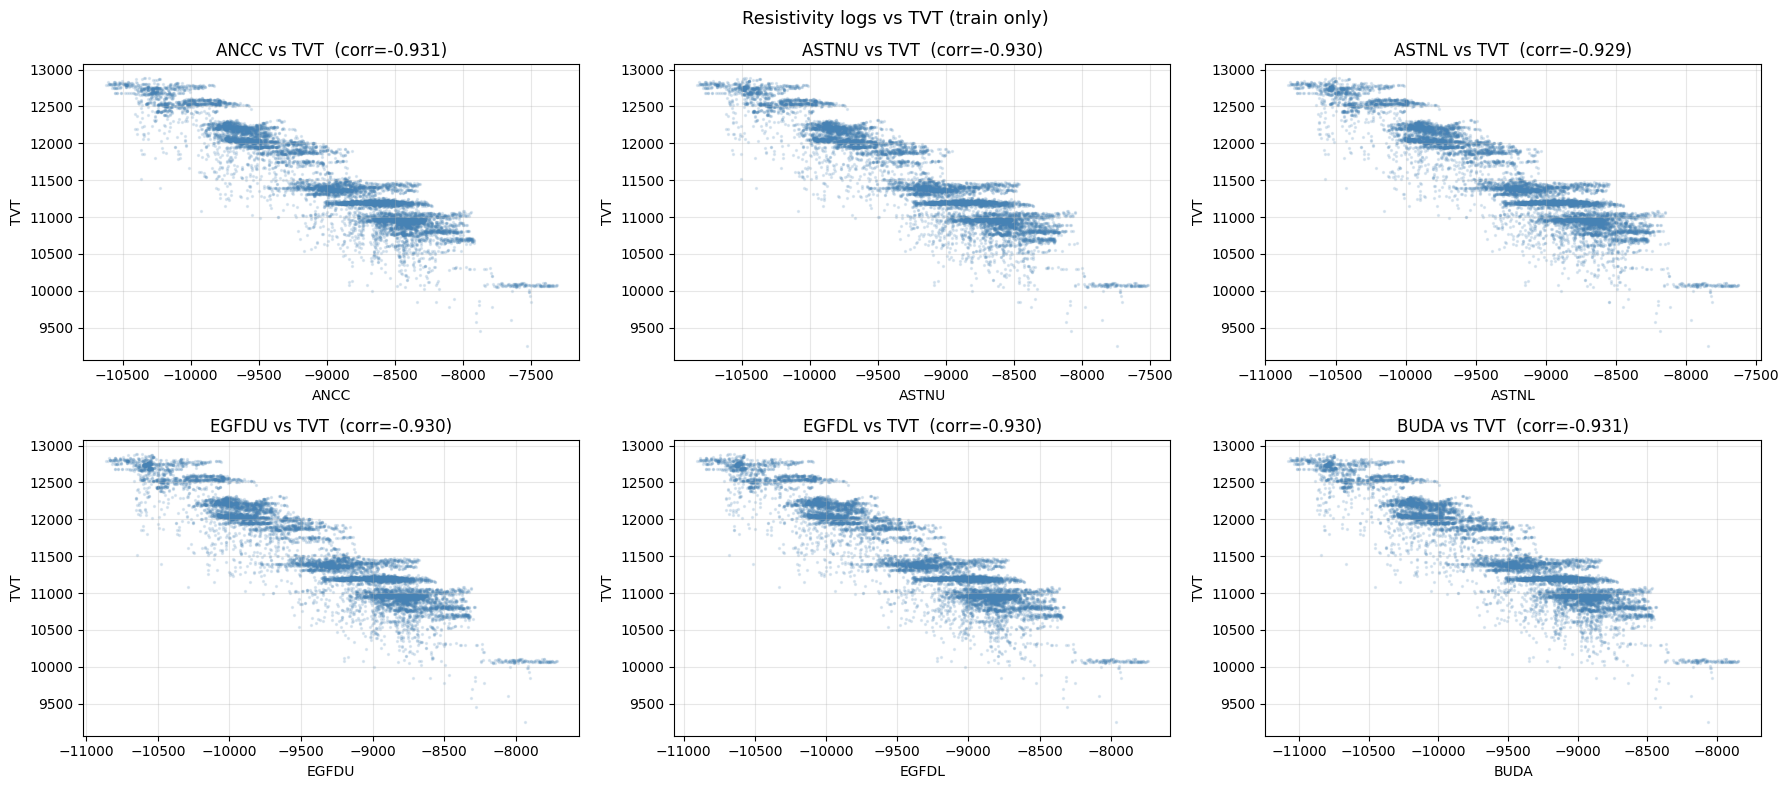

In [8]:
resist_available = [c for c in RESIST_COLS if c in train.columns]
print(f'Resistivity cols in train: {resist_available}')
print('(These are NOT available in test — cannot be direct model features)\n')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flatten(), resist_available):
    ax.scatter(train[col].iloc[sample_idx],
               train[TARGET_COL].iloc[sample_idx],
               alpha=0.15, s=2, c='steelblue')
    corr = train[[col, TARGET_COL]].corr().iloc[0, 1]
    ax.set_title(f'{col} vs TVT  (corr={corr:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('TVT')
plt.suptitle('Resistivity logs vs TVT (train only)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Single Well Deep Dive

Largest well: d90aa14c  (12,141 rows)


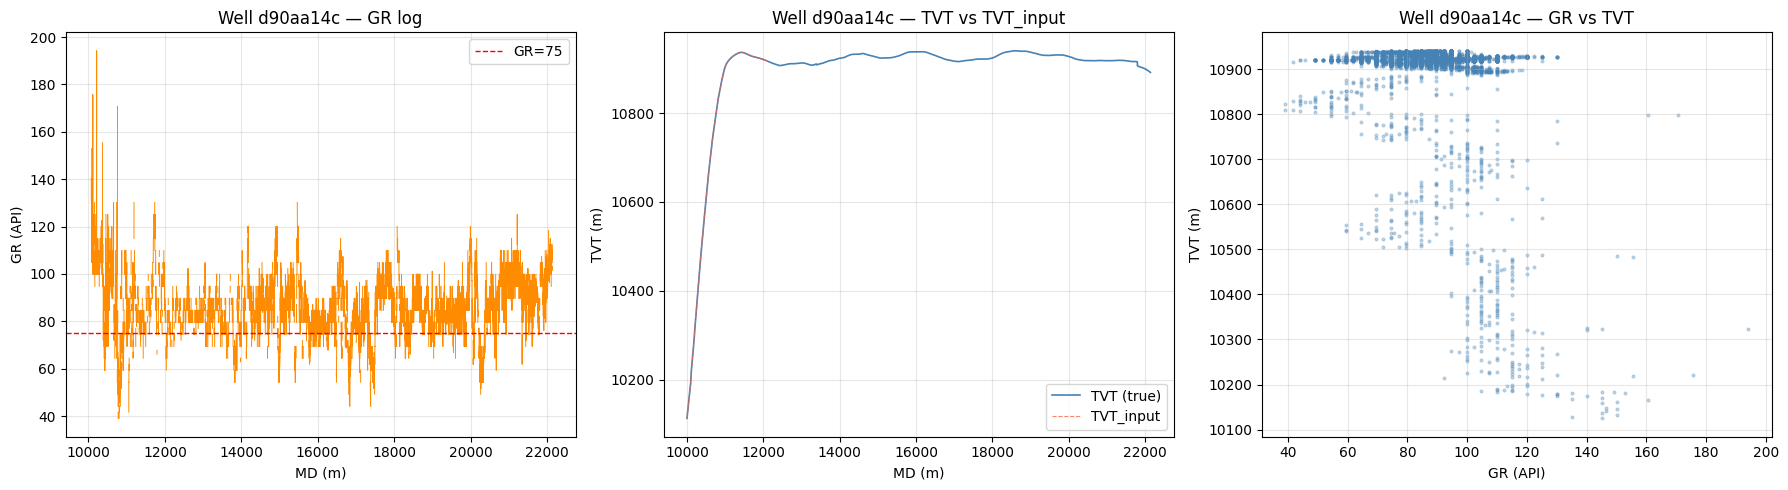

In [9]:
# Pick the largest train well
well_sizes = train.groupby(WELL_COL).size().sort_values(ascending=False)
sample_well = well_sizes.index[0]
print(f'Largest well: {sample_well}  ({well_sizes.iloc[0]:,} rows)')

w = train[train[WELL_COL] == sample_well].sort_values(DEPTH_COL)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(w[DEPTH_COL], w[GR_COL], lw=0.7, color='darkorange')
axes[0].set_title(f'Well {sample_well} — GR log')
axes[0].set_xlabel('MD (m)')
axes[0].set_ylabel('GR (API)')
axes[0].axhline(75, color='red', ls='--', lw=1, label='GR=75')
axes[0].legend()

axes[1].plot(w[DEPTH_COL], w[TARGET_COL], lw=1.2, color='steelblue', label='TVT (true)')
axes[1].plot(w[DEPTH_COL], w[TVTINPUT_COL], lw=0.8, color='tomato',
             ls='--', alpha=0.8, label='TVT_input')
axes[1].set_title(f'Well {sample_well} — TVT vs TVT_input')
axes[1].set_xlabel('MD (m)')
axes[1].set_ylabel('TVT (m)')
axes[1].legend()

axes[2].scatter(w[GR_COL], w[TARGET_COL], alpha=0.3, s=4, c='steelblue')
axes[2].set_title(f'Well {sample_well} — GR vs TVT')
axes[2].set_xlabel('GR (API)')
axes[2].set_ylabel('TVT (m)')

plt.tight_layout()
plt.show()

## 8. Typewell Alignment

Typewell columns: ['TVT', 'GR', 'Geology']
        TVT     GR Geology
0  10100.45  135.2     NaN
1  10101.45  135.2     NaN
2  10102.45  138.2     NaN
3  10103.45  140.2     NaN
4  10104.45  138.2     NaN
Shape: (864, 3)


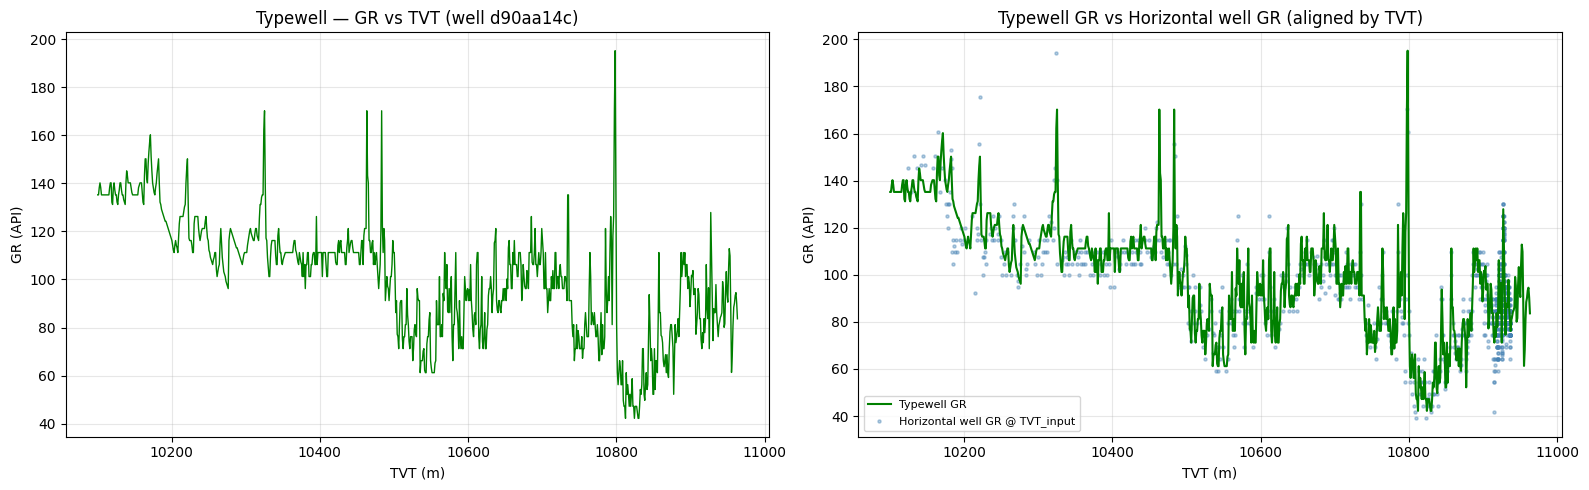

In [10]:
# Load typewell directly for the sample well
tw_path = DATA_DIR / 'train' / f'{sample_well}__typewell.csv'
tw = pd.read_csv(tw_path)
print('Typewell columns:', list(tw.columns))
print(tw.head())
print(f'Shape: {tw.shape}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Typewell GR vs TVT
axes[0].plot(tw['TVT'], tw['GR'], lw=1, color='green', label='Typewell GR')
axes[0].set_title(f'Typewell — GR vs TVT (well {sample_well})')
axes[0].set_xlabel('TVT (m)')
axes[0].set_ylabel('GR (API)')

# Overlay: horizontal well GR vs TVT_input vs Typewell GR vs TVT
axes[1].plot(tw['TVT'], tw['GR'], lw=1.5, color='green', label='Typewell GR')
axes[1].scatter(w[TVTINPUT_COL], w[GR_COL],
                alpha=0.4, s=5, c='steelblue', label='Horizontal well GR @ TVT_input')
axes[1].set_title('Typewell GR vs Horizontal well GR (aligned by TVT)')
axes[1].set_xlabel('TVT (m)')
axes[1].set_ylabel('GR (API)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. 3D Wellbore Trajectory

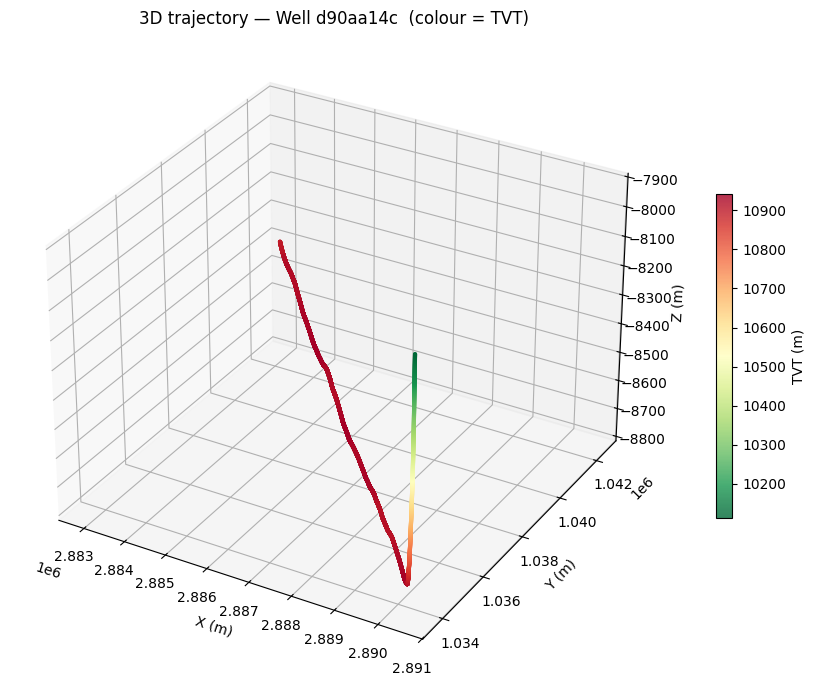

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    w[X_COL], w[Y_COL], w[Z_COL],
    c=w[TARGET_COL], cmap='RdYlGn_r', s=4, alpha=0.8
)
plt.colorbar(sc, ax=ax, label='TVT (m)', shrink=0.5)
ax.set_title(f'3D trajectory — Well {sample_well}  (colour = TVT)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
plt.tight_layout()
plt.show()

## 10. Well Size Distribution

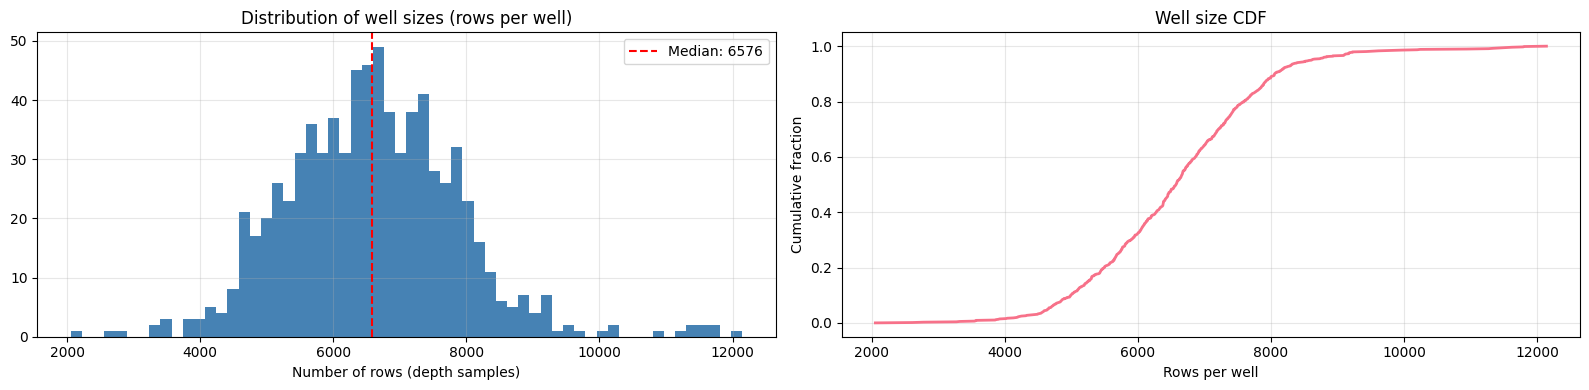

Rows per well: min=2058, median=6576, max=12141


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(well_sizes.values, bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of well sizes (rows per well)')
axes[0].set_xlabel('Number of rows (depth samples)')
axes[0].axvline(well_sizes.median(), color='red', ls='--', lw=1.5,
                label=f'Median: {well_sizes.median():.0f}')
axes[0].legend()

# Cumulative
sorted_sizes = np.sort(well_sizes.values)
axes[1].plot(sorted_sizes, np.linspace(0, 1, len(sorted_sizes)), lw=2)
axes[1].set_title('Well size CDF')
axes[1].set_xlabel('Rows per well')
axes[1].set_ylabel('Cumulative fraction')

plt.tight_layout()
plt.show()

print(f'Rows per well: min={well_sizes.min()}, median={well_sizes.median():.0f}, max={well_sizes.max()}')

## 11. TVT Autocorrelation

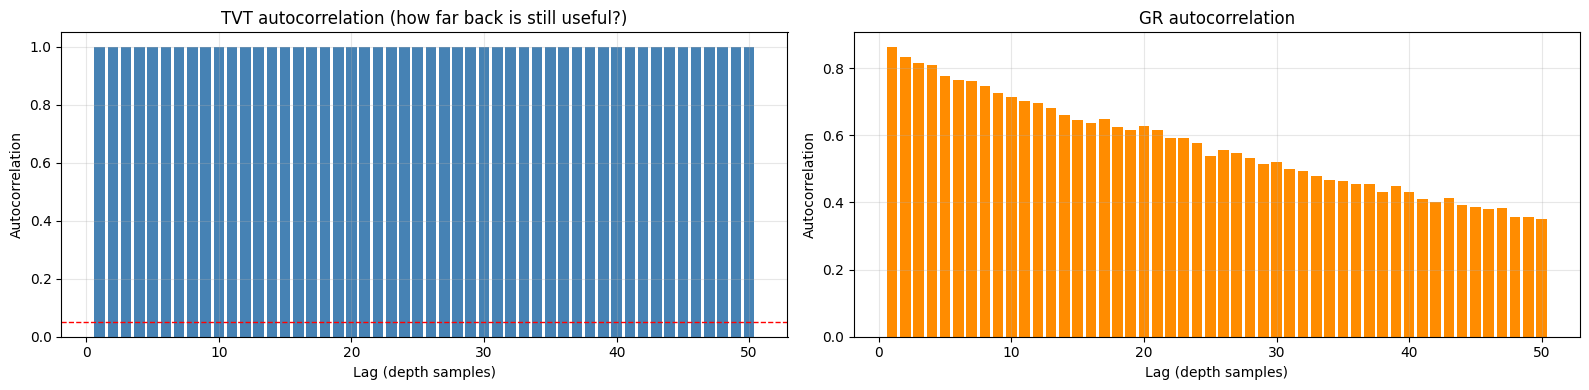

TVT autocorr drops below 0.05 at lag None → use lag features up to ~None


In [13]:
# Use largest well for stable estimate
tvt_series = w.sort_values(DEPTH_COL)[TARGET_COL]
gr_series  = w.sort_values(DEPTH_COL)[GR_COL]

lags = range(1, 51)
tvt_acf = [tvt_series.autocorr(lag=k) for k in lags]
gr_acf  = [gr_series.autocorr(lag=k)  for k in lags]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(list(lags), tvt_acf, color='steelblue')
axes[0].set_title('TVT autocorrelation (how far back is still useful?)')
axes[0].set_xlabel('Lag (depth samples)')
axes[0].set_ylabel('Autocorrelation')
axes[0].axhline(0.05, color='red', ls='--', lw=1)

axes[1].bar(list(lags), gr_acf, color='darkorange')
axes[1].set_title('GR autocorrelation')
axes[1].set_xlabel('Lag (depth samples)')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

first_below_5 = next((l for l, v in zip(lags, tvt_acf) if v < 0.05), None)
print(f'TVT autocorr drops below 0.05 at lag {first_below_5} → use lag features up to ~{first_below_5}')

## 12. Test Wells vs Train Wells

Test well IDs: ['000d7d20', '00bbac68', '00e12e8b']


These wells also in train: True

Submission rows: 14151
          count   min   max
well_id                    
000d7d20   3836  1442  5277
00bbac68   6014  1545  7558
00e12e8b   4301  2083  6383


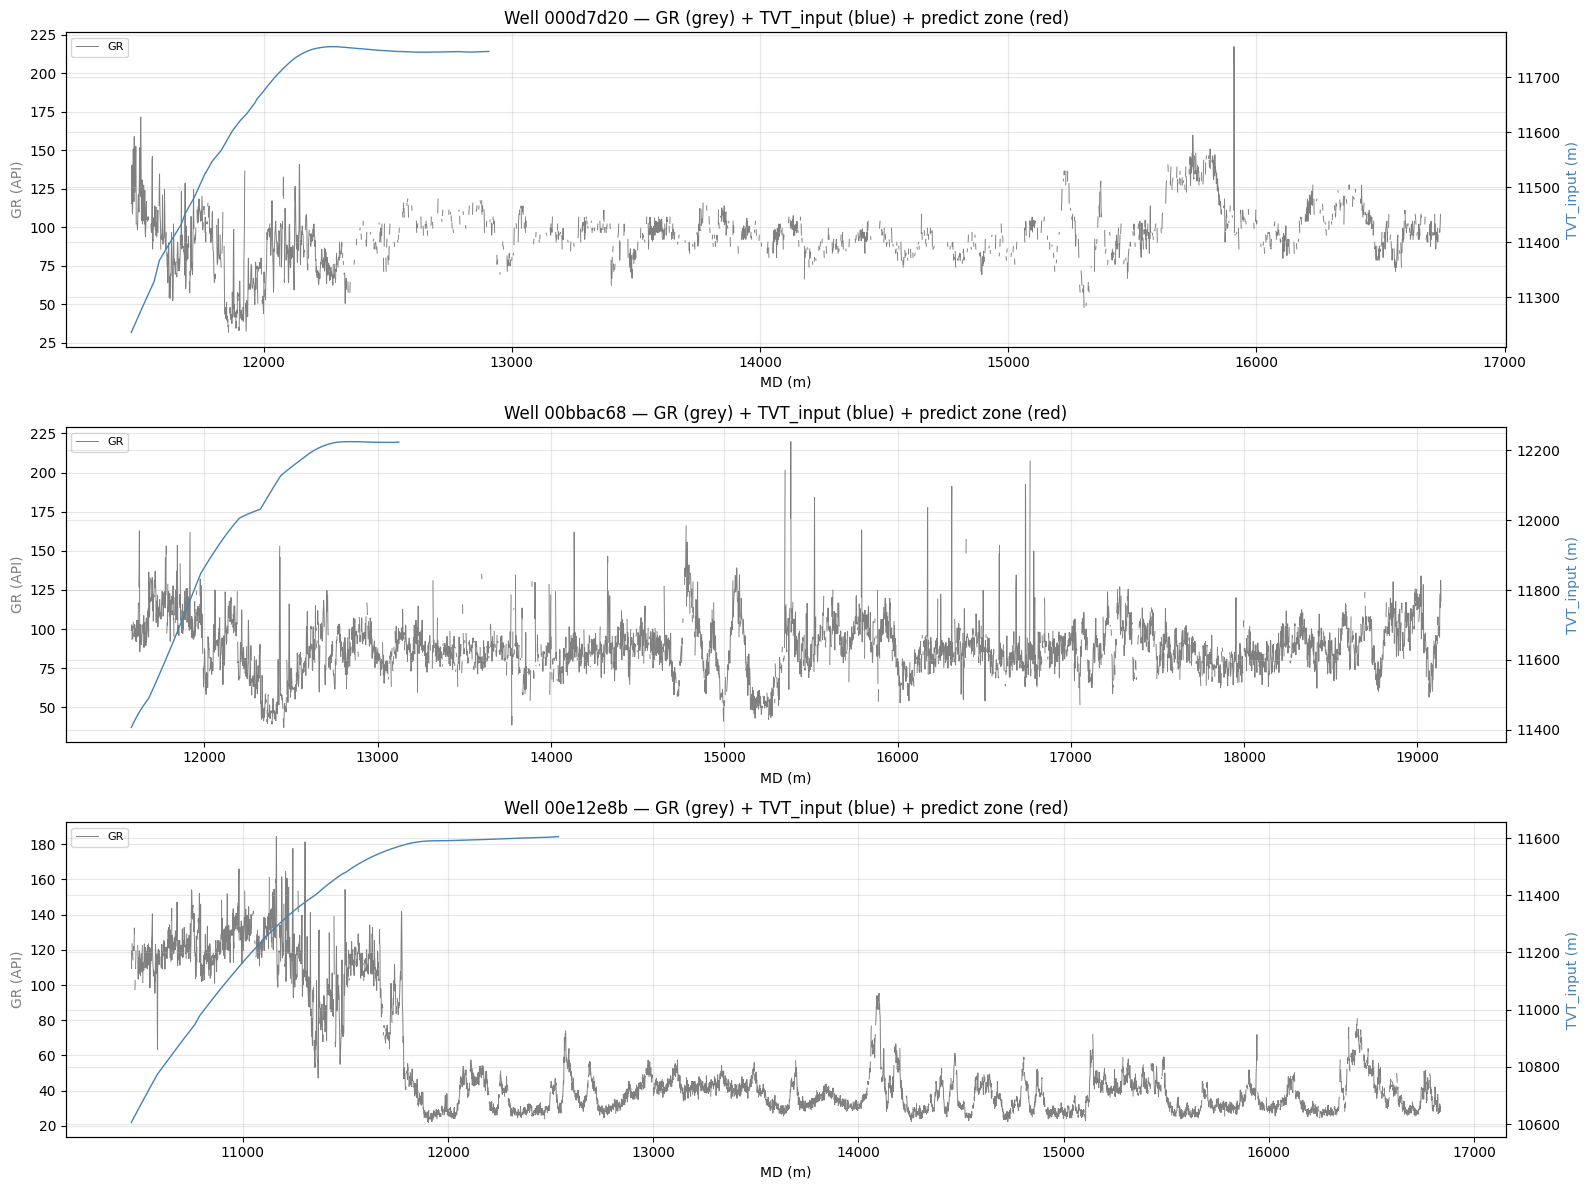

In [14]:
test_well_ids = test[WELL_COL].unique()
print(f'Test well IDs: {list(test_well_ids)}')
print(f'These wells also in train: {all(w in train[WELL_COL].unique() for w in test_well_ids)}')

sub_ids = sample_sub['id'].str.rsplit('_', n=1, expand=True)
sub_ids.columns = ['well_id', 'row_idx']
sub_ids['row_idx'] = sub_ids['row_idx'].astype(int)

print(f'\nSubmission rows: {len(sample_sub)}')
print(sub_ids.groupby('well_id')['row_idx'].agg(['count', 'min', 'max']))

# Visualise which rows are to predict for each test well
fig, axes = plt.subplots(len(test_well_ids), 1,
                          figsize=(16, 4 * len(test_well_ids)))
if len(test_well_ids) == 1:
    axes = [axes]

for ax, wid in zip(axes, test_well_ids):
    tw_df  = test[test[WELL_COL] == wid].sort_values(DEPTH_COL)
    mask   = tw_df[TVTINPUT_COL] == 0
    sub_wi = sub_ids[sub_ids['well_id'] == wid]['row_idx'].values

    ax.plot(tw_df[DEPTH_COL], tw_df[GR_COL], lw=0.7, color='grey', label='GR')
    ax2 = ax.twinx()
    ax2.plot(tw_df[DEPTH_COL], tw_df[TVTINPUT_COL], lw=1, color='steelblue',
             label='TVT_input')
    # Shade unknown regions
    unknown_depths = tw_df[mask][DEPTH_COL].values
    if len(unknown_depths):
        ax.axvspan(unknown_depths[0], unknown_depths[-1],
                   alpha=0.15, color='red', label='Predict zone')
    ax.set_title(f'Well {wid} — GR (grey) + TVT_input (blue) + predict zone (red)')
    ax.set_xlabel('MD (m)')
    ax.set_ylabel('GR (API)', color='grey')
    ax2.set_ylabel('TVT_input (m)', color='steelblue')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 13. Correlation Matrix

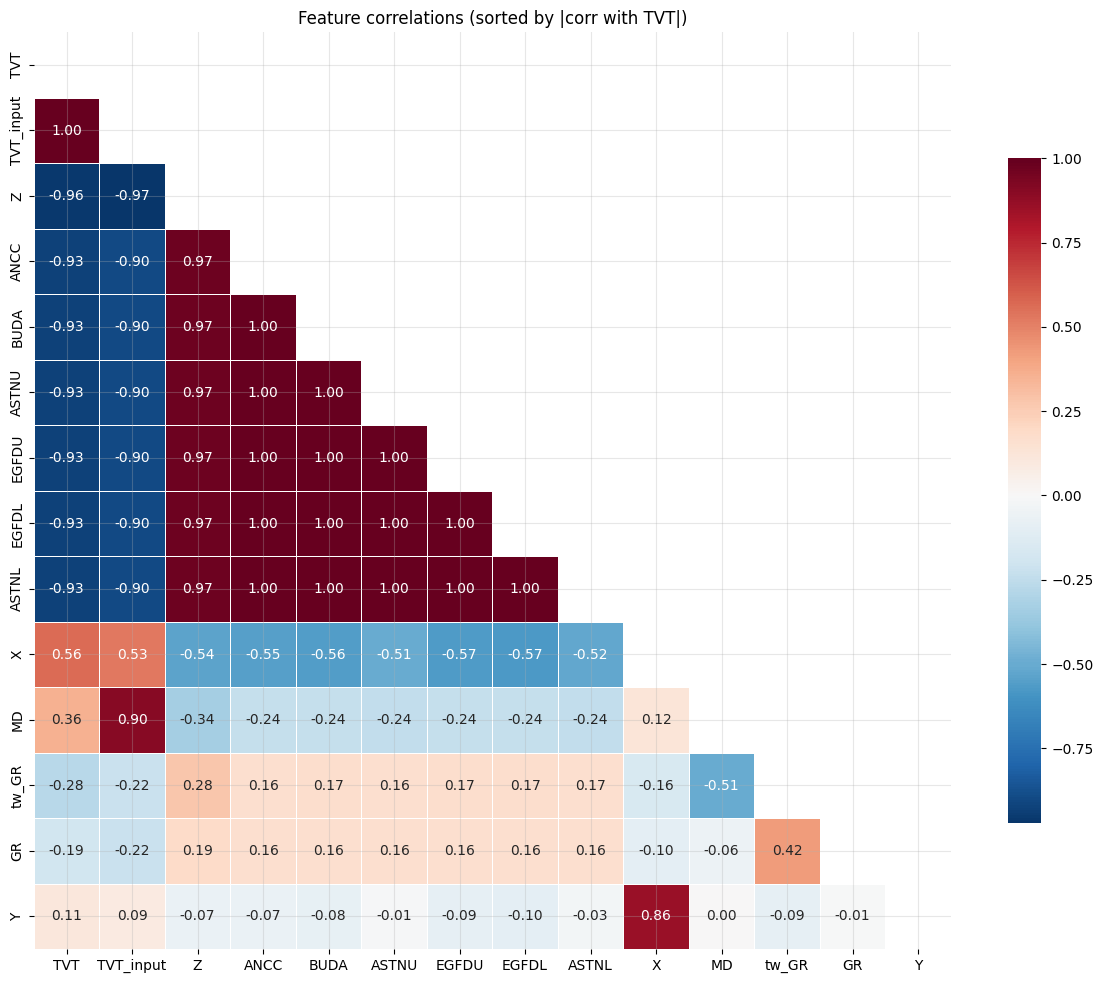

In [15]:
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ['row_idx']]
corr = train[num_cols].corr()
order = corr[TARGET_COL].abs().sort_values(ascending=False).index
corr = corr.loc[order, order]

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4, square=True,
            cbar_kws={'shrink': 0.7})
plt.title('Feature correlations (sorted by |corr with TVT|)')
plt.tight_layout()
plt.show()

## 14. EDA Summary

| Finding | Implication |
|---|---|
| `TVT_input` ≈ TVT in train (near-perfect match) | `TVT_input` is the strongest feature — known anchors constrain the prediction |
| `TVT_input = 0` in test for rows to predict | Task is interpolation between anchor points |
| GR mean varies widely across wells | Normalize GR per-well or vs typewell |
| Typewell GR matches horizontal GR when aligned by TVT | Cross-correlation with typewell = powerful feature |
| TVT autocorrelation stays high for ~20–50 lags | Include lag features up to lag 20–30 |
| 3 test wells = same wells as in train | Test is interpolation, not extrapolation to new geology |
| Resistivity logs correlated with TVT (train only) | Can't use as features; consider as auxiliary training signal |

→ Proceed to `02_modeling.ipynb`